In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [102]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [103]:
# Load Excel file
source_file = pd.ExcelFile('OrganDonor_Consolidated.xlsx')

# Initialize an empty dictionary to store DataFrames
dfs = {}

# Iterate over each sheet name
for sheet_name in source_file.sheet_names:
    # Load the sheet into a DataFrame
    df = source_file.parse(sheet_name)
    # Modify the sheet name to create a key for the dictionary
    key = sheet_name + '_df'
    # Store the DataFrame in the dictionary with the modified name as the key
    dfs[key] = df

In [104]:
# Access the required DataFrames directly
DonorDetails_df = dfs['DonorDetails_df']
ReferralDetails_df = dfs['ReferralDetails_df']
Outcomes_df = dfs['Outcomes_df']
OPO_HospDetails_df = dfs['OPO_HospDetails_df']
Yearly_Outcomes_df = dfs['Yearly_Outcomes_df']

In [105]:
# Print the shapes of all DataFrames
for df_name, df in dfs.items():
    print(f"{df_name}: {df.shape}")
    print(f"{df_name}: {df.info()}")

DonorDetails_df: (133101, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133101 entries, 0 to 133100
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientID           133101 non-null  object        
 1   age                 133017 non-null  float64       
 2   gender              133040 non-null  object        
 3   race                133101 non-null  object        
 4   causeofdeath        133101 non-null  object        
 5   mechanism_of_death  133101 non-null  object        
 6   brain_death         133101 non-null  int64         
 7   time_asystole       89446 non-null   datetime64[ns]
 8   time_brain_death    11856 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 9.1+ MB
DonorDetails_df: None
ReferralDetails_df: (133101, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133101 entries, 0 to 133100
Data columns (total 

### 1: Distribution of mechanism of death between diffrent age groups

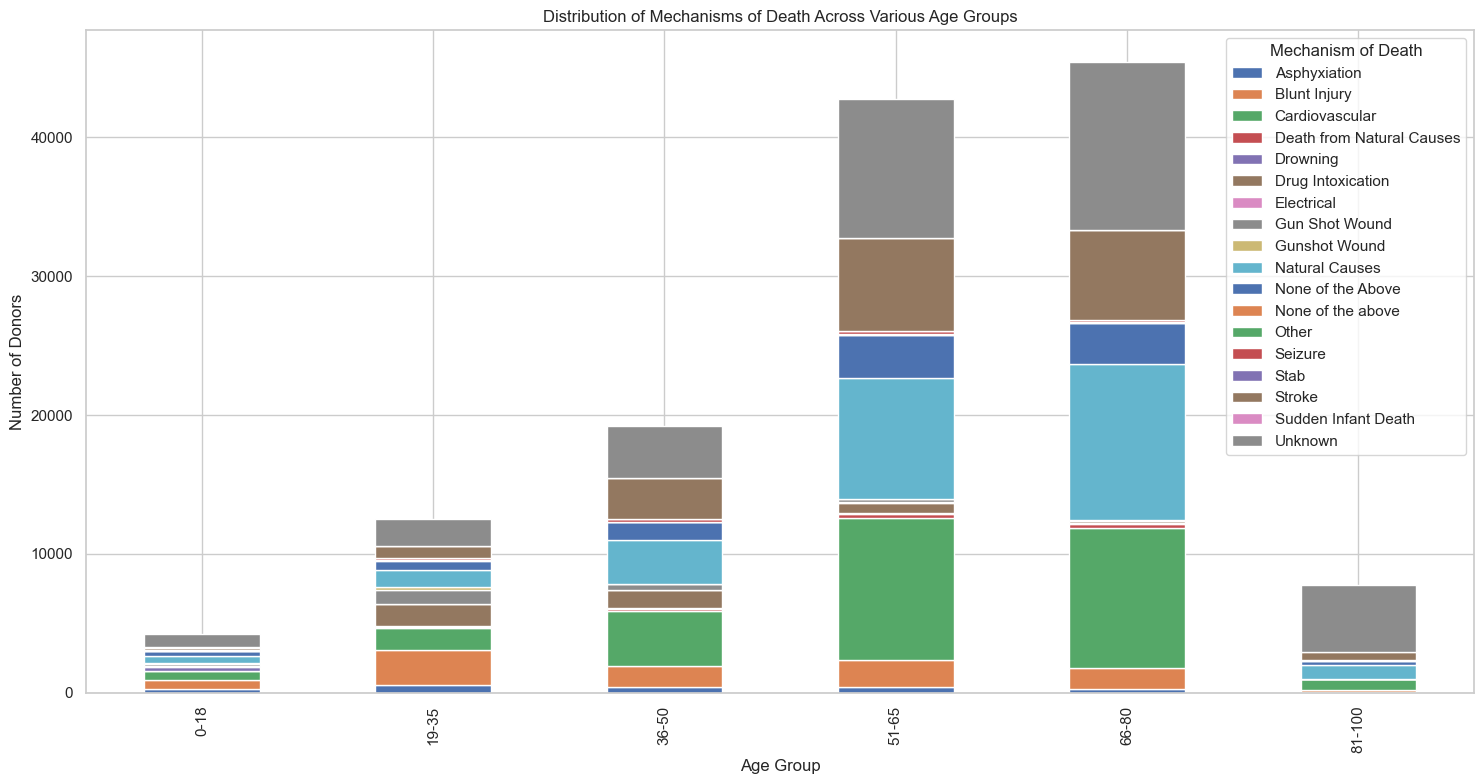

In [121]:
df1= DonorDetails_df

# create age groups
bins = [0, 18, 35, 50, 65, 80, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66-80', '81-100']

# new column for age groups
df1['age_group'] = pd.cut(df1['age'], bins=bins, labels=labels, right=False)

# Group by age group and mechanism of death
age_mech_counts = df1.groupby(['age_group', 'mechanism_of_death']).size().unstack()

# Plot the chart
age_mech_counts.plot(kind='bar', stacked=True, figsize=(15, 8))

# cutomization
plt.title('Distribution of Mechanisms of Death Across Various Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Donors')
plt.legend(title='Mechanism of Death')


plt.tight_layout()
plt.show()



### 2: Create a bar graph to visualize the top 10 most common causes of death for donors under 25 years old.

             Cause_of_Death  Count
0                    Anoxia   2654
1               Head Trauma   2496
2                   Unknown   1215
3                     Other    363
4            Cardiac Arrest    277
5  cerebrovascular accident    262
6                    Trauma    191
7       Respiratory - Other    169
8                       GSW    128
9                    Sepsis     98


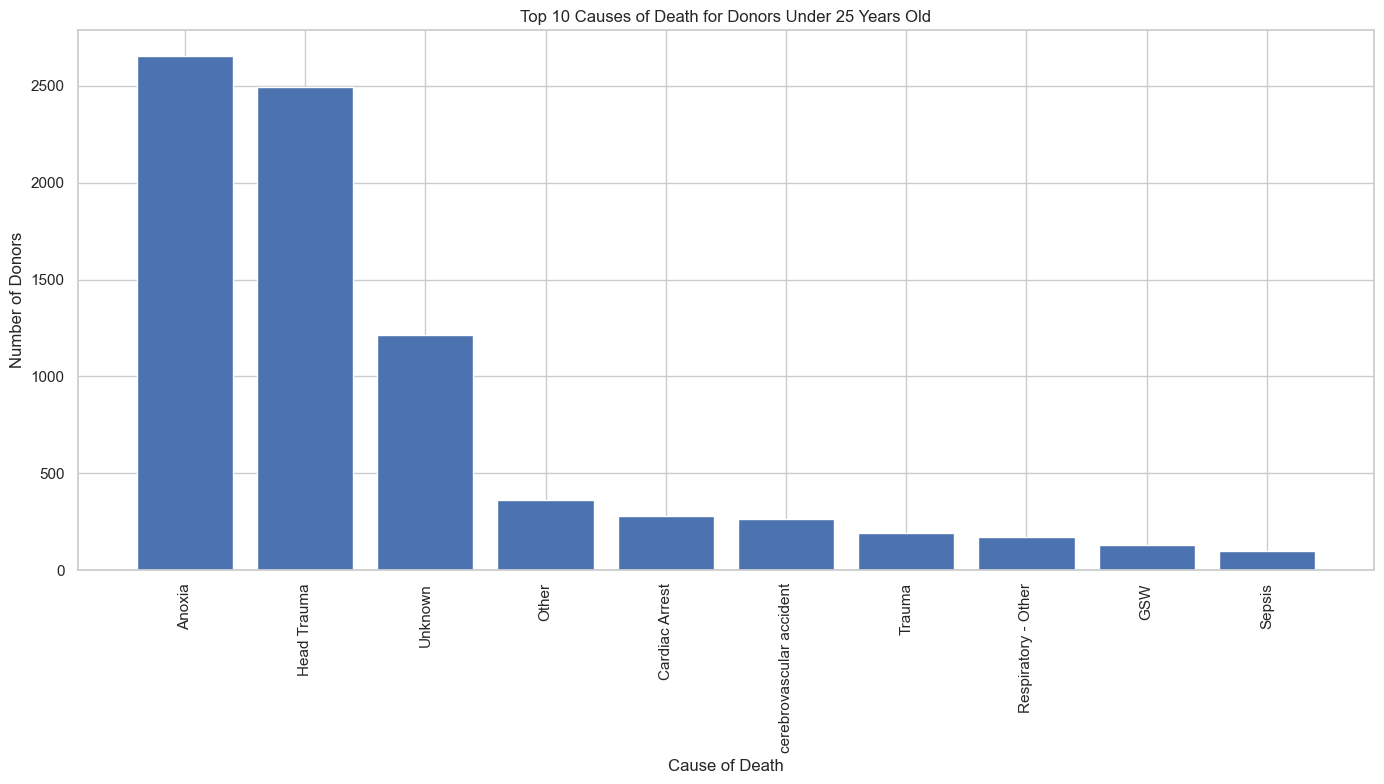

In [124]:
# Filter the under 25 years old donors
donors_under_25 = DonorDetails_df[DonorDetails_df['age'] < 25]

# no. of donors for each cause of death
cause_of_death_counts = donors_under_25['causeofdeath'].value_counts().reset_index()

# column renaming
cause_of_death_counts.columns = ['Cause_of_Death', 'Count']

# top 10 causes of death
top_10_causes = cause_of_death_counts.head(10)
print(top_10_causes)

# Plot bar graph
plt.figure(figsize=(14, 8))
plt.bar(top_10_causes['Cause_of_Death'], top_10_causes['Count'])

# Customization
plt.title('Top 10 Causes of Death for Donors Under 25 Years Old')
plt.xlabel('Cause of Death')
plt.ylabel('Number of Donors')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()


### 3: Gender distribution of donors by top 10 causes of death 

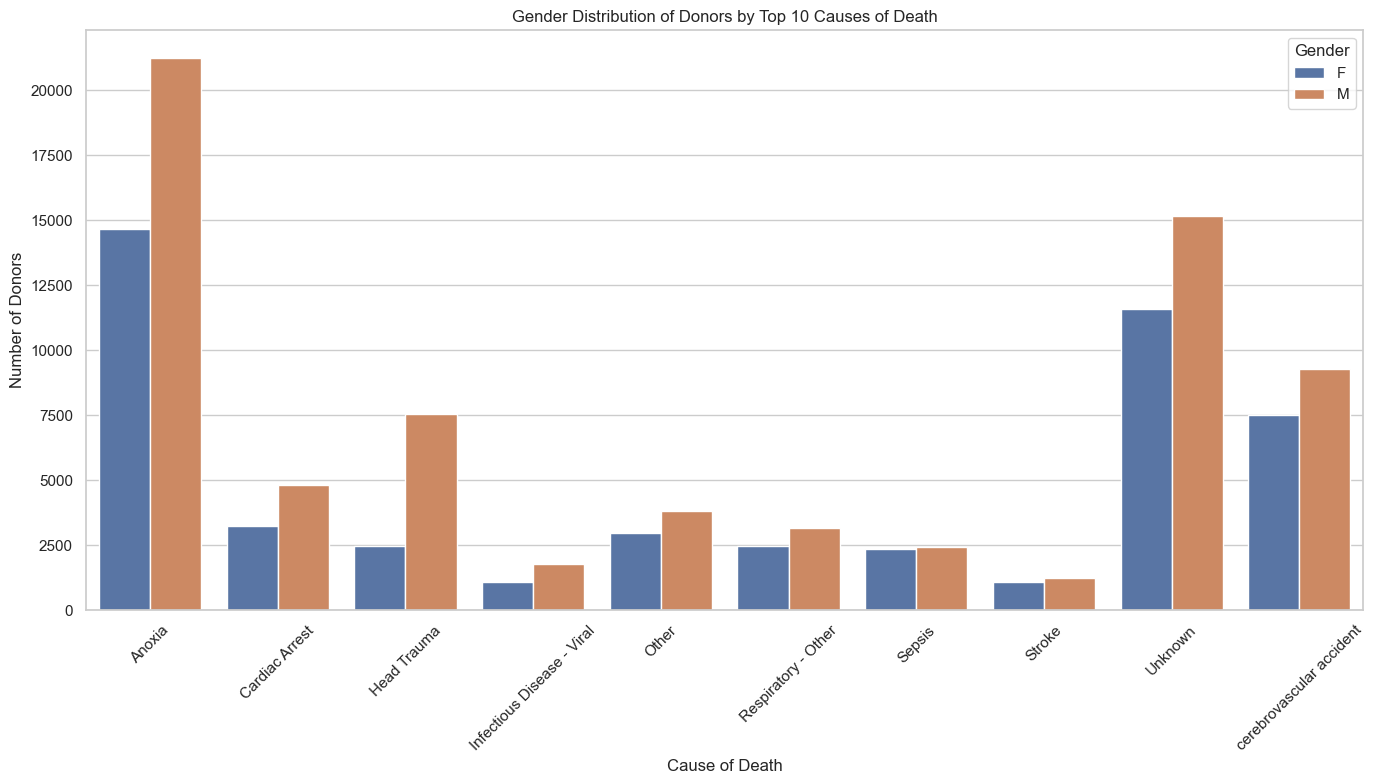

In [129]:

# Grouping data by cause of death and gender and counting no. of donors
gender_distribution = DonorDetails_df.groupby(['causeofdeath', 'gender']).size().reset_index(name='count')

# top 10 causes of death
top_causes = gender_distribution.groupby('causeofdeath')['count'].sum().nlargest(10).index

# Filtering data to include top 10 causes of death
top_gender_distribution = gender_distribution[gender_distribution['causeofdeath'].isin(top_causes)]

# Plot the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='causeofdeath', y='count', hue='gender', data=top_gender_distribution)

# customization
plt.title('Gender Distribution of Donors by Top 10 Causes of Death')
plt.xlabel('Cause of Death')
plt.ylabel('Number of Donors')
plt.xticks(rotation=45)
plt.legend(title='Gender')


plt.tight_layout()
plt.show()


### 4: Distribution of Donor's ages by OPO.

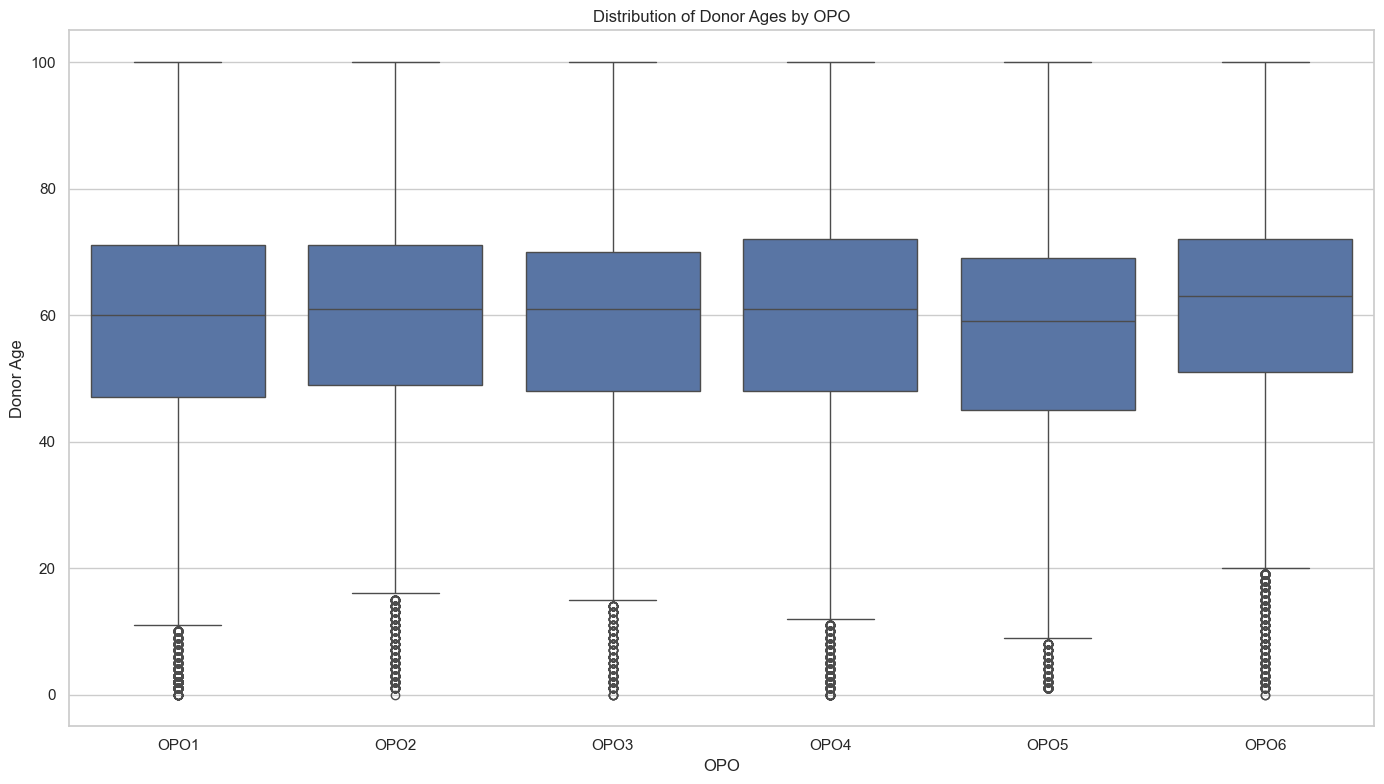

In [136]:
# Data merging on Patient ID
merged_df = pd.merge(DonorDetails_df[['PatientID', 'age']], OPO_HospDetails_df[['PatientID', 'OPO']], on='PatientID', how='inner')

# Removeing null values 
merged_df = merged_df.dropna(subset=['age', 'OPO'])

# Ploting box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='OPO', y='age', data=merged_df)

# Customization
plt.title('Distribution of Donor Ages by OPO')
plt.xlabel('OPO')
plt.ylabel('Donor Age')

plt.tight_layout()
plt.show()


### 5: Top 5 Mechanism of death for Sepsis.

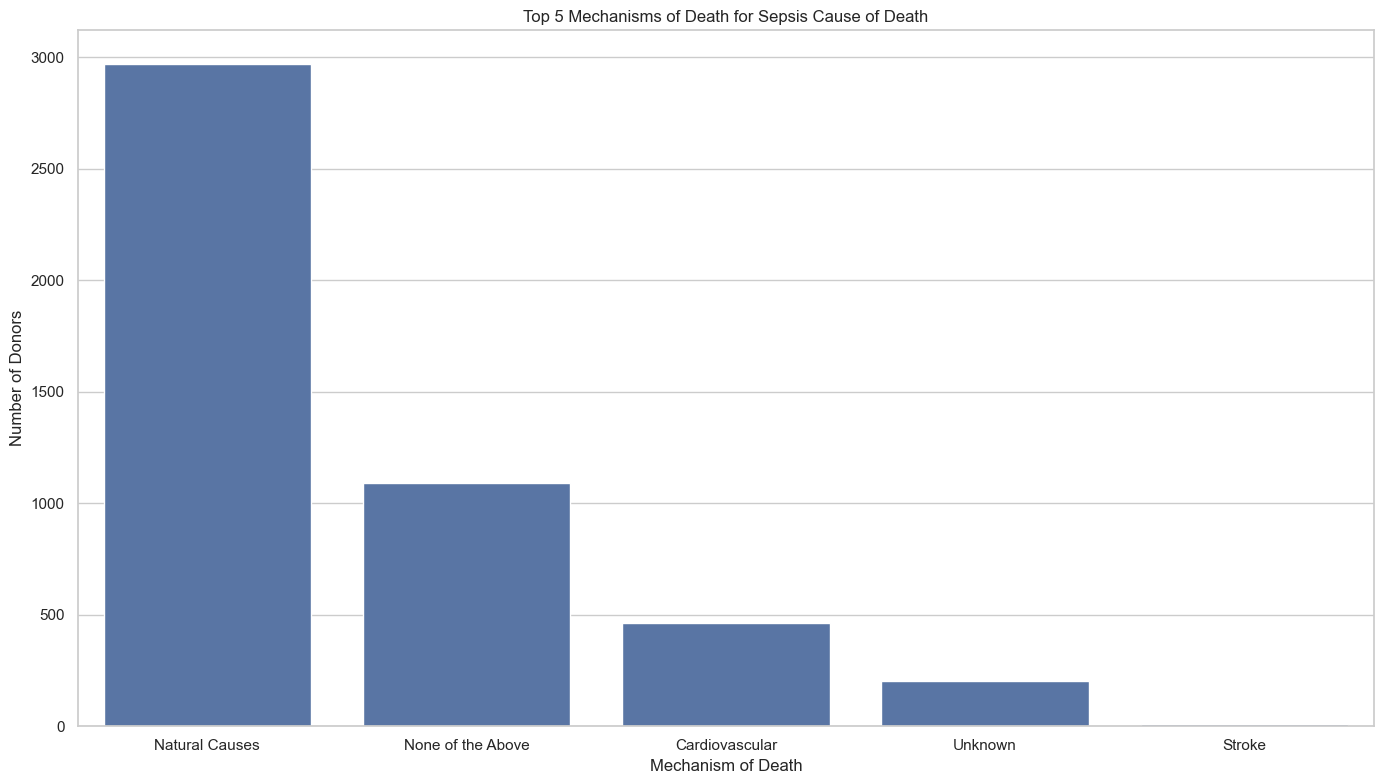

In [143]:

# Filtered dataset 
sepsis_donors = DonorDetails_df[DonorDetails_df['causeofdeath'].str.lower() == 'sepsis']

# Droping null values
sepsis_donors = sepsis_donors.dropna(subset=['mechanism_of_death'])

# Grouping data by mechanism of death and counting donors
mechanism_of_death_counts = sepsis_donors.groupby('mechanism_of_death').size().reset_index(name='count')

# Top 5 mechanisms of death
top_mechanisms = mechanism_of_death_counts.nlargest(5, 'count')

# Plot the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='mechanism_of_death', y='count', data=top_mechanisms)

# Customization
plt.title('Top 5 Mechanisms of Death for Sepsis Cause of Death')
plt.xlabel('Mechanism of Death')
plt.ylabel('Number of Donors')

plt.tight_layout()
plt.show()
